In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import image
from google.colab import files

In [ ]:
events = [i for i in dir(cv2) if 'EVENT' in i]
print(events)

['EVENT_FLAG_ALTKEY', 'EVENT_FLAG_CTRLKEY', 'EVENT_FLAG_LBUTTON', 'EVENT_FLAG_MBUTTON', 'EVENT_FLAG_RBUTTON', 'EVENT_FLAG_SHIFTKEY', 'EVENT_LBUTTONDBLCLK', 'EVENT_LBUTTONDOWN', 'EVENT_LBUTTONUP', 'EVENT_MBUTTONDBLCLK', 'EVENT_MBUTTONDOWN', 'EVENT_MBUTTONUP', 'EVENT_MOUSEHWHEEL', 'EVENT_MOUSEMOVE', 'EVENT_MOUSEWHEEL', 'EVENT_RBUTTONDBLCLK', 'EVENT_RBUTTONDOWN', 'EVENT_RBUTTONUP']


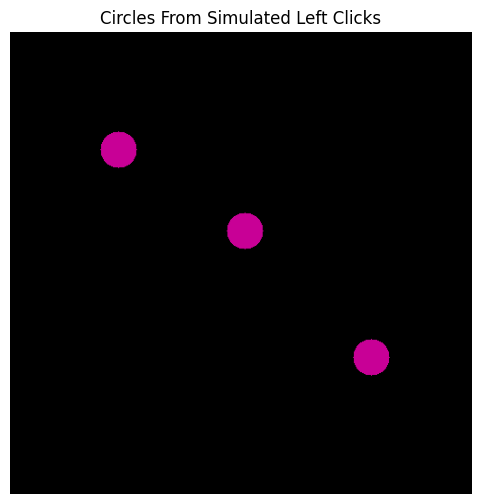

In [ ]:
img = np.zeros((512, 512, 3), dtype=np.uint8)

click_points = [(120, 130), (260, 220), (400, 360)]

def draw_circle(event, x, y, flags=None, param=None):
  if event == cv2.EVENT_LBUTTONDOWN:
    cv2.circle(img, (x, y), 20, (150, 0, 200), -1)

for x, y in click_points:
  draw_circle(cv2.EVENT_LBUTTONDOWN, x, y)

plt.figure(figsize=(6, 6))
plt.imshow(img[..., ::-1])
plt.title('Circles From Simulated Left Clicks')
plt.axis('off')
plt.show()

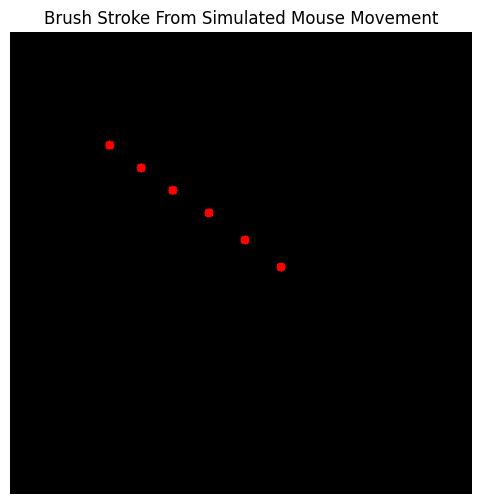

In [ ]:
img = np.zeros((512, 512, 3), dtype=np.uint8)
drawing = False

def brush(event, x, y, flags=None, param=None):
  global drawing
  if event == cv2.EVENT_LBUTTONDOWN:
    drawing = True
  elif event == cv2.EVENT_MOUSEMOVE and drawing:
    cv2.circle(img, (x, y), 5, (0, 0, 255), -1)
  elif event == cv2.EVENT_LBUTTONUP:
    drawing = False

stroke = [(80, 100), (110, 125), (145, 150), (180, 175), (220, 200), (260, 230), (300, 260)]
brush(cv2.EVENT_LBUTTONDOWN, *stroke[0])

for point in stroke[1:]:
  brush(cv2.EVENT_MOUSEMOVE, *point)
brush(cv2.EVENT_LBUTTONUP, *stroke[-1])

plt.figure(figsize=(6, 6))
plt.imshow(img[..., ::-1])
plt.title('Brush Stroke From Simulated Mouse Movement')
plt.axis('off')
plt.show()

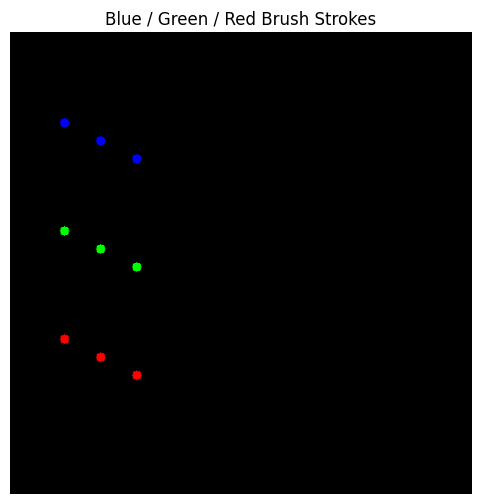

In [ ]:
img = np.zeros((512, 512, 3), dtype=np.uint8)
drawing = False

def color_brush(event, x, y, flags=None, param=None):
  global drawing, color
  if event == cv2.EVENT_LBUTTONDOWN:
    drawing = True
  elif event == cv2.EVENT_MOUSEMOVE and drawing:
    cv2.circle(img, (x, y), 5, color, -1)
  elif event == cv2.EVENT_LBUTTONUP:
    drawing = False

stroke = [(
    ((255, 0, 0), [(60, 100), (100, 120), (140, 140)]),
    ((0, 255, 0), [(60, 220), (100, 240), (140, 260)]),
    ((0, 0, 255), [(60, 340), (100, 360), (140, 380)])
)]

for selected_color, points in stroke[0]:
  color = selected_color
  for point in points:
    color_brush(cv2.EVENT_LBUTTONDOWN, *points[0])
    for _ in range(5):
      color_brush(cv2.EVENT_MOUSEMOVE, *point)
    color_brush(cv2.EVENT_LBUTTONUP, *points[-1])

plt.figure(figsize=(6, 6))
plt.imshow(img[..., ::-1])
plt.title('Blue / Green / Red Brush Strokes')
plt.axis('off')
plt.show()

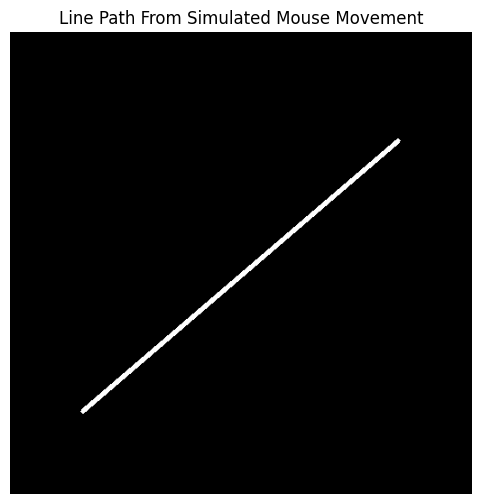

In [ ]:
img = np.zeros((512, 512, 3), dtype=np.uint8)
drawing = False
ix, iy = 0, 0

def draw_line(event, x, y, flags=None, param=None):
  global drawing, ix, iy
  if event == cv2.EVENT_LBUTTONDOWN:
    drawing = True
    ix, iy = x, y
  elif event == cv2.EVENT_MOUSEMOVE and drawing:
    cv2.line(img, (ix, iy), (x, y), (255, 255, 255), 3)
    ix, iy = x, y
  elif event == cv2.EVENT_LBUTTONUP:
    drawing = False

line_path = [(80, 420), (150, 360), (220, 300), (290, 240), (360, 180), (430, 120)]
draw_line(cv2.EVENT_LBUTTONDOWN, *line_path[0])

for point in line_path[1:]:
  draw_line(cv2.EVENT_MOUSEMOVE, *point)
draw_line(cv2.EVENT_LBUTTONUP, *line_path[-1])

plt.figure(figsize=(6, 6))
plt.imshow(img[..., ::-1])
plt.title('Line Path From Simulated Mouse Movement')
plt.axis('off')
plt.show()

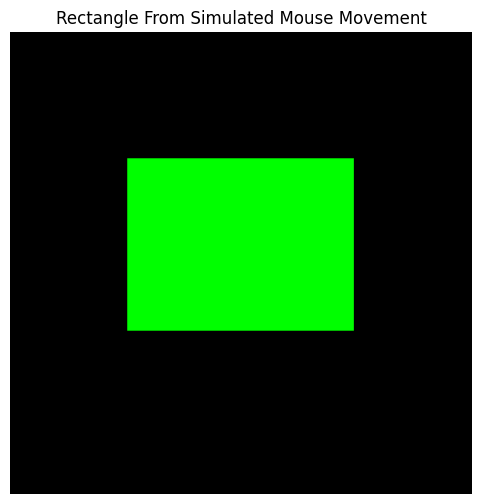

In [ ]:
img = np.zeros((512, 512, 3), dtype=np.uint8)
drawing = False
start_point = (0, 0)
current_image = img.copy()

def draw_rectangle(event, x, y, flags=None, param=None):
  global drawing, start_point, current_image
  if event == cv2.EVENT_LBUTTONDOWN:
    drawing = True
    start_point = (x, y)
  elif event == cv2.EVENT_MOUSEMOVE and drawing:
    current_image = img.copy()
    cv2.rectangle(current_image, start_point, (x, y), (0, 255, 0), -1)
  elif event == cv2.EVENT_LBUTTONUP:
    drawing = False
    cv2.rectangle(img, start_point, (x, y), (0, 255, 0), -1)
    current_image = img.copy()

rectangle_start = (130, 140)
rectangle_end = (380, 330)
draw_rectangle(cv2.EVENT_LBUTTONDOWN, *rectangle_start)
draw_rectangle(cv2.EVENT_MOUSEMOVE, *rectangle_end)
draw_rectangle(cv2.EVENT_LBUTTONUP, *rectangle_end)

plt.figure(figsize=(6, 6))
plt.imshow(img[..., ::-1])
plt.title('Rectangle From Simulated Mouse Movement')
plt.axis('off')
plt.show()

In [ ]:
uploaded = files.upload()
image_name = next(iter(uploaded))
image_path = '/content/' + image_name
image = cv2.imread(image_path)

if image is None:
  raise ValueError('Image Not Read')

print('Selected Image:', image_path)
print('Image Shape:', image.shape)

Saving input.jpg to input (1).jpg
Selected Image: /content/input (1).jpg
Image Shape: (600, 800, 3)


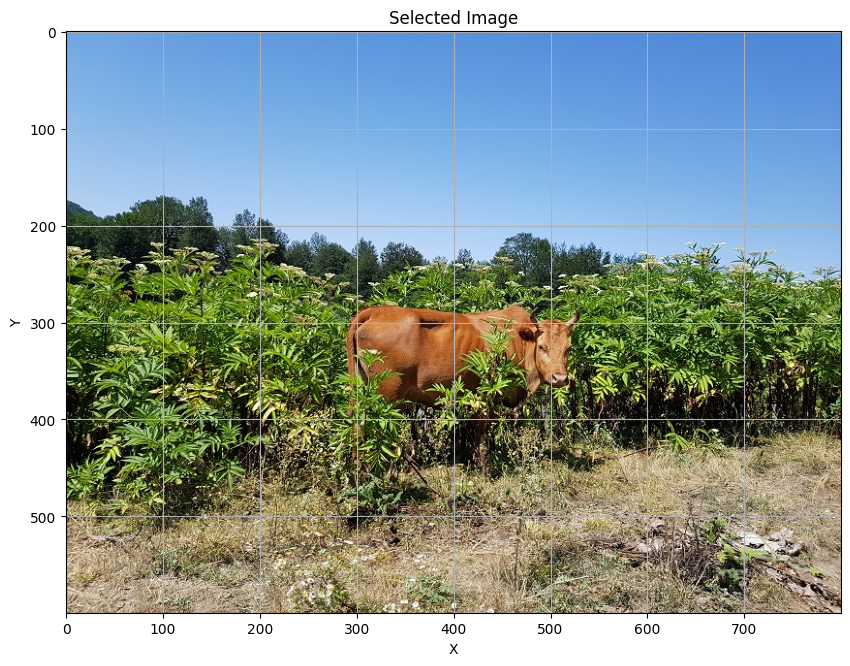

In [ ]:
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))
plt.imshow(image_rgb)
plt.title('Selected Image')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid()
plt.show()

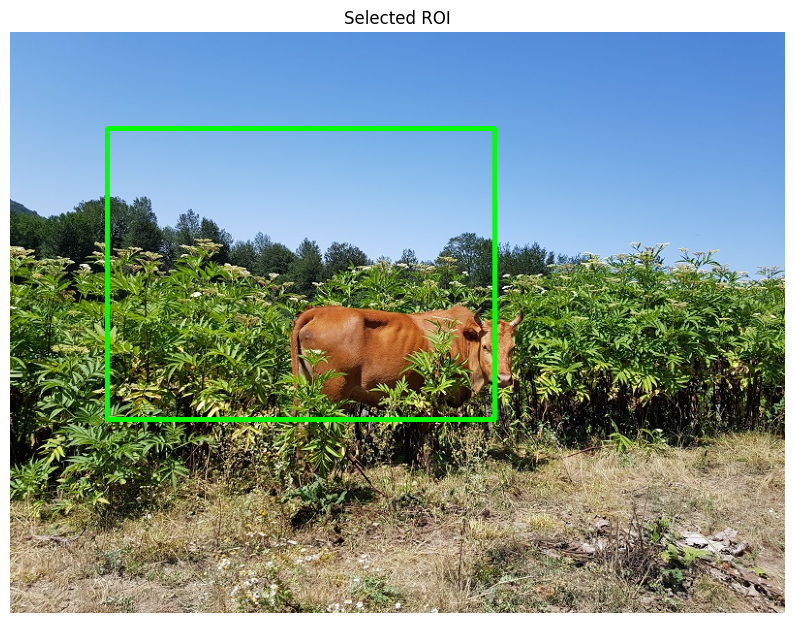

In [ ]:
x1, y1 = 100, 100
x2, y2 = min(500, image.shape[1] -1), min(400, image.shape[0] -1)

selected = image.copy()
points = [(x1, y1), (x2, y2)]
cv2.rectangle(selected, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.figure(figsize=(10, 8))
plt.imshow(selected[..., ::-1])
plt.title('Selected ROI')
plt.axis('off')
plt.show()

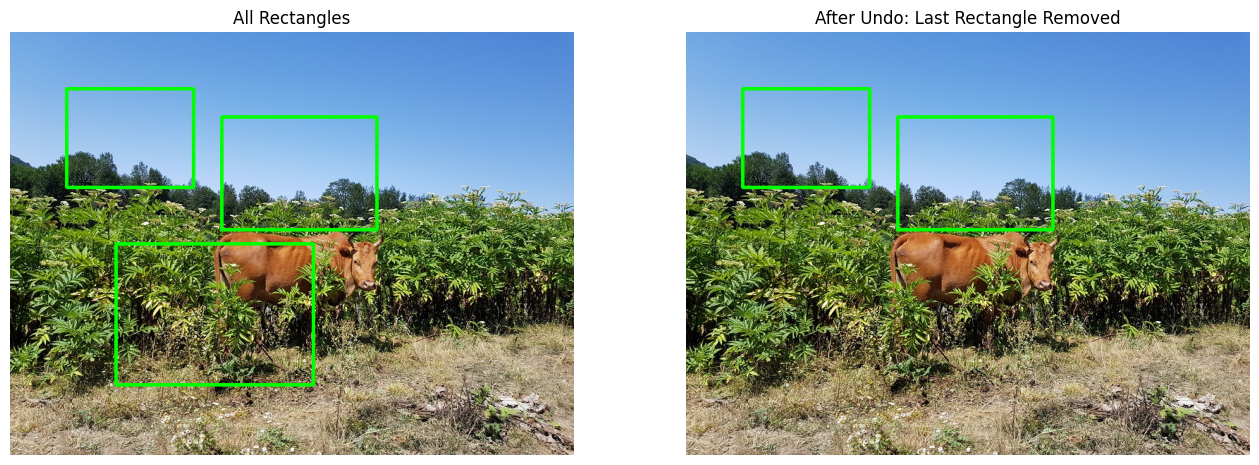

All Points: [((80, 80), (260, 220)), ((300, 120), (520, 280)), ((150, 300), (430, 500))]
After Undo: [((80, 80), (260, 220)), ((300, 120), (520, 280))]


In [ ]:
rectangles = [
    ((80, 80), (260, 220)),
    ((300, 120), (520, 280)),
    ((150, 300), (430, 500))
]

annotated = image.copy()
for start, end in rectangles:
  cv2.rectangle(annotated, start, end, (0, 255, 0), 3)

rectangles_after_undo = rectangles[:-1]
undo_image = image.copy()
for start, end in rectangles_after_undo:
  cv2.rectangle(undo_image, start, end, (0, 255, 0), 3)

plt.figure(figsize=(16, 7))
plt.subplot(121)
plt.imshow(annotated[..., ::-1])
plt.title('All Rectangles')
plt.axis('off')
plt.subplot(122)
plt.imshow(undo_image[..., ::-1])
plt.title('After Undo: Last Rectangle Removed')
plt.axis('off')
plt.show()

print('All Points:', rectangles)
print('After Undo:', rectangles_after_undo)